# Buổi 4: Tìm kiếm trong không gian trạng thái

### Bài 1. Biễu diễn đồ thị

Cho đồ thị hàm số **G** (**V**, **E**) như bên dưới:

![image](dothi.png)

#### 1. Biễu diễn bằng danh sách / ma trận kề

In [2]:
ADJ= {
    'A': {'C', 'E', 'D', 'F'},
    'B': {},
    'C': {'H'},
    'D': {'H', 'E'},
    'E': {'K', 'I'},
    'F': {'I', 'G'},
    'G': {},
    'H': {'K'},
    'I': {'B', 'K'},
    'K': {'B'}
}

In [3]:
import pprint
pprint.pprint(ADJ)

{'A': {'E', 'D', 'C', 'F'},
 'B': {},
 'C': {'H'},
 'D': {'E', 'H'},
 'E': {'K', 'I'},
 'F': {'I', 'G'},
 'G': {},
 'H': {'K'},
 'I': {'K', 'B'},
 'K': {'B'}}


#### 2. Thao tác duyệt đồ thị
(a) Liệt kê các đỉnh trong đồ thị <br/>
(b) Liệt kê tất cả các cạnh đồ thị hiển thị dạng danh sách kề <br/>
(c) Cho hai đỉnh A, B. Hỏi hai đỉnh A, B có kề nhau không? <br/>
(d) Cho một đỉnh A. Hỏi danh sách các đỉnh kề với A <br/>

In [4]:
print("2. Thao tác duyệt đồ thị")

2. Thao tác duyệt đồ thị


In [5]:
print("(a) Liệt kê các đỉnh trong đồ thị")
print("Các đỉnh của đồ thị: ", end = " ")
vertices = list(ADJ.keys())  # ADJ đang ở dạng list, với các bộ key - value
print(vertices)
# ...

(a) Liệt kê các đỉnh trong đồ thị
Các đỉnh của đồ thị:  ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K']


In [6]:
print("(b) Liệt kê tất cả các cạnh đồ thị hiển thị dạng danh sách kề")
print("Danh sách kề của đồ thị: ")

def HienThiDoThi(G):
    for u in G:
        print(f'Đỉnh {u}:', end = ' ')
        for v in G[u]:
            print(f'{v}' ,end = ' ')
        print()
    # ...
    
    pass

HienThiDoThi(ADJ)

(b) Liệt kê tất cả các cạnh đồ thị hiển thị dạng danh sách kề
Danh sách kề của đồ thị: 
Đỉnh A: E D C F 
Đỉnh B: 
Đỉnh C: H 
Đỉnh D: E H 
Đỉnh E: K I 
Đỉnh F: I G 
Đỉnh G: 
Đỉnh H: K 
Đỉnh I: K B 
Đỉnh K: B 


In [7]:
print("(c) Cho hai đỉnh A, B. Hỏi hai đỉnh A, B có kề nhau không?")

def LaKe(G, a, b):
    """
    input: G, a, b
    return: 
    + -1: dinh a, hay b khong ton tai
    +  0: dinh a, b ton tai va a khong ke b
    +  1: dinh a, b ton tai va a, b ke nhau
    """
    result = None
    if a in G and b in G:
        if b in G[a]:
            result = 1
        else: result = 0
    else: result = -1
    # ...  
    return result

(c) Cho hai đỉnh A, B. Hỏi hai đỉnh A, B có kề nhau không?


In [8]:
a = "L"; b = "R"; print(f"{a} ke {b}: {LaKe(ADJ, a, b)}")
a = "A"; b = "R"; print(f"{a} ke {b}: {LaKe(ADJ, a, b)}")
a = "E"; b = "D"; print(f"{a} ke {b}: {LaKe(ADJ, a, b)}")
a = "D"; b = "E"; print(f"{a} ke {b}: {LaKe(ADJ, a, b)}")

L ke R: -1
A ke R: -1
E ke D: 0
D ke E: 1


In [9]:
print("(d) Cho một đỉnh A. Hỏi danh sách các đỉnh kề với A")

def LayKe(G, a):
    """
    input: G, a
    return: 
    + None: neu a khong ton tai
    + []  : a khong ke voi bat ky dinh nao
    + [x, y, ...]: mang cac dinh ke voi a
    """
    result = None
    
    if a in G:
        result = []
        for v in G[a]:
            result.append(v)
    # ...
    
    return result

a = "P"; print(f"Danh sach ke voi dinh {a}: {LayKe(ADJ, a)}")
a = "A"; print(f"Danh sach ke voi dinh {a}: {LayKe(ADJ, a)}")
a = "B"; print(f"Danh sach ke voi dinh {a}: {LayKe(ADJ, a)}")
a = "D"; print(f"Danh sach ke voi dinh {a}: {LayKe(ADJ, a)}")

(d) Cho một đỉnh A. Hỏi danh sách các đỉnh kề với A
Danh sach ke voi dinh P: None
Danh sach ke voi dinh A: ['E', 'D', 'C', 'F']
Danh sach ke voi dinh B: []
Danh sach ke voi dinh D: ['E', 'H']


#### 3. Đọc và lưu đồ thị
**dske.txt**
```
10           # số đỉnh đồ thị
A C E F D    # đỉnh A kề với C E F D
B            # đỉnh B không kề với ai
C H
D E H
E K I
F I G
G
H K
I K B
K B
```

In [10]:
print("1. Lưu đồ thị xuống tập tin")

def LuuDoThi(G, file_path, verbose = True):
    import os
    
    
    # Tạo thư mục chứa file_path
    file_dir = os.path.dirname(file_path)
    if file_dir != "" and os.path.exists(file_path) == False:
        os.makedirs(file_dir)
        if verbose: print(f"+ Tao thu muc: {file_dir}")
    
    # Lưu đồ thị
    with open(file_path, "wt") as file:
        file.write(f'{len(G)}\n')
        for u in G:
            file.write(f'{u} ')
            for v in G[u]:
                file.write(f'{v} ')
            file.write('\n')
        # ...
        
        if verbose: print(f"Luu do thi thanh cong xuong tap tin: {file_path}")
    pass

LuuDoThi(ADJ, "dske1.txt", verbose = True)
with open("dske1.txt", "rt") as file:
    lines = file.readlines()
    for line in lines: print(line, end="")

1. Lưu đồ thị xuống tập tin
Luu do thi thanh cong xuong tap tin: dske1.txt
10
A E D C F 
B 
C H 
D E H 
E K I 
F I G 
G 
H K 
I K B 
K B 


In [11]:
print("2. Đọc đồ thị từ tập tin")
import pprint

def DocDoThi(file_path, verbose = True):
    """
    return:
    + None: doc that bai
    + <>None: tra ve do thi
    """
    import os
    
    result = None
    if os.path.exists(file_path) == False:
        result = None
    else:
        G = {}
        with open(file_path, "rt") as file:
            n = int(file.readline())
            for line in file: 
                row = line.split()                  ## chia dòng thành các phần tử
                if not row: continue                ## bỏ dòng trống
                u, *next_u  = row                   ## UNPACKING lấy u là phần tử đầu, next_u là các phần tử còn lại
                neighbor = {v: 1 for v in next_u}   ## tạo dict đỉnh kề
                G[u] = set(neighbor)                ## đưa về set để tránh lặp đỉnh
            # ...  
            pass
        result = G
    return result

G1 = DocDoThi("dske1.txt", verbose = True)
pprint.pprint(G1)

2. Đọc đồ thị từ tập tin
{'A': {'E', 'D', 'C', 'F'},
 'B': set(),
 'C': {'H'},
 'D': {'E', 'H'},
 'E': {'K', 'I'},
 'F': {'I', 'G'},
 'G': set(),
 'H': {'K'},
 'I': {'K', 'B'},
 'K': {'B'}}


### Bài 2. Tìm kiếm đường đi trên đồ thị

#### 1. Tìm kiếm theo chiều rộng (BFS)

In [12]:
import pprint
def BFS(G, start, goal):
    """
    return: 
    + mang chua duong di tu a --> b, neu rong la ko co duong di
    + None: dinh a, b khong hop le
    """
    if G.get(start) is None or G.get(goal) is None:
        return None
    else:
        path = {}     # path[a]=b nghia la muon di toi dinh b phai qua a
        s_open   = []
        s_closed = []
        # đưa start vào open
        s_open.append(start)    

        found = False
        path[start] = None
        while len(s_open)>0:
            u = s_open.pop(0)
            s_closed.append(u)
            if u == goal:
                print(f'Da tim duoc dương di tu {start} toi {goal}')
                found = True
                break
                
            for v in sorted(G[u]): ## Có sắp xếp đỉnh lại khi duyệt kề
                if v not in s_closed and v not in s_open:
                    path[v] = u
                    s_open.append(v)
            # ...
            pass
        if not found: 
            print(f'Khong co dương di tu {start} toi {goal}')
            return {}

    return path

In [13]:
path = BFS(ADJ, "A","B")
pprint.pprint(path)

Da tim duoc dương di tu A toi B
{'A': None,
 'B': 'I',
 'C': 'A',
 'D': 'A',
 'E': 'A',
 'F': 'A',
 'G': 'F',
 'H': 'C',
 'I': 'E',
 'K': 'E'}


##### Mô phỏng cây tìm kiếm BFS

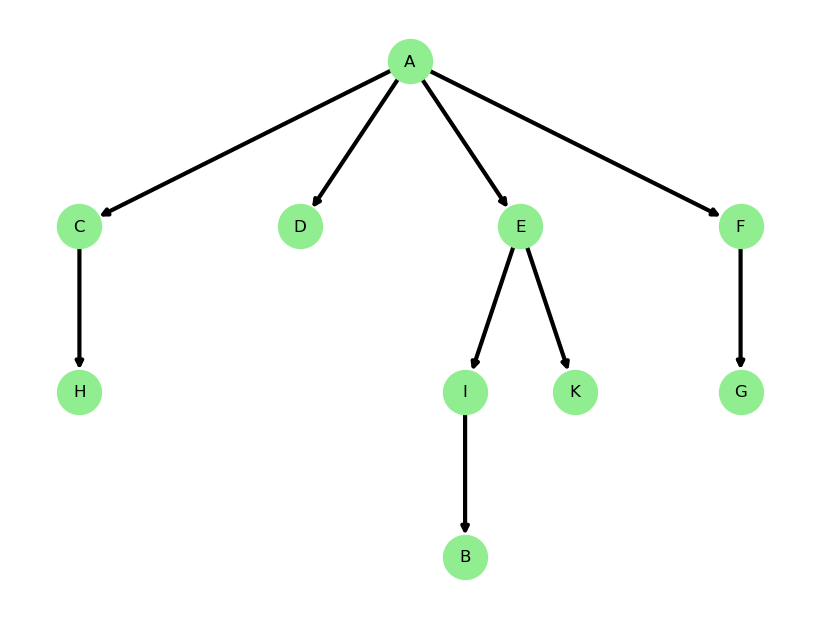

In [14]:

import networkx as nx
import matplotlib.pyplot as plt
def hierarchy_pos(G, root, width=1., vert_gap=0.2, vert_loc=1, xcenter=0.5):
    pos = {}

    def _hierarchy_pos(G, root, left, right, vert_loc, pos):
        pos[root] = ((left + right) / 2, vert_loc)
        children = list(G.successors(root))
        if children:
            dx = (right - left) / len(children)
            nextx = left
            for child in children:
                nextx += dx
                pos = _hierarchy_pos(G, child, nextx - dx, nextx, vert_loc - vert_gap, pos)
        return pos

    return _hierarchy_pos(G, root, 0, width, vert_loc, pos)

G = nx.DiGraph()
for u in ADJ:
    for v in sorted(ADJ[u]):
        G.add_edge(u,v)

plt.figure(figsize=(8, 6))

P = nx.bfs_tree(G, source='A')
pos = hierarchy_pos(P,'A')

nx.draw(P, pos, with_labels=True,node_size=1000, node_color="lightgreen" ,width=3 )
plt.savefig("bfs.png")
plt.show()


##### Hàm tìm đường với các đỉnh

In [15]:
def find_path(path, start, goal):
    """
    Cho mang truy hoi duong, tim ds dinh tu start --> goal
    """
    result = []
    if goal not in path: return []
    cur = goal
    while cur != start:
        result.append(cur)
        cur = path.get(cur)
        if cur is None:
            return []
    # ...
    pass
    result.append(start)
    result.reverse()
    return result

In [16]:
find_path(path, 'A', 'B')

['A', 'E', 'I', 'B']

#### 2. Tìm kiếm theo chiều sâu (DFS)

In [17]:
import pprint
def DFS(G, start, goal):
    """
    return: 
    + mang chua duong di tu a --> b, neu rong la ko co duong di
    + None: dinh a, b khong hop le
    """
    if G.get(start) is None or G.get(goal) is None:
        return None
    else:
        path = {}     # path[a]=b nghia la muon di toi dinh b phai qua a
        s_open   = []
        s_closed = []
        # đưa start vào open
        s_open.append(start)    

        found = False
        path[start] = None
        while len(s_open)>0:
            u = s_open.pop()
            s_closed.append(u)
            if u == goal:
                print(f'Da tim duoc dương di tu {start} toi {goal}')
                found = True
                break
            for v in reversed(sorted(G[u])): ## sort đỉnh theo chiều pop
                if v not in s_closed and v not in s_open:
                    path[v] = u
                    s_open.append(v)
            # ...
            pass
        if not found: 
            print(f'Khong co dương di tu {start} toi {goal}')
            return {}

    return path

In [18]:
path2 = DFS(ADJ, "A", "B")
pprint.pprint(path2)

Da tim duoc dương di tu A toi B
{'A': None,
 'B': 'K',
 'C': 'A',
 'D': 'A',
 'E': 'A',
 'F': 'A',
 'H': 'C',
 'K': 'H'}


In [19]:
find_path(path2, "A","B")

['A', 'C', 'H', 'K', 'B']

##### Mô phỏng cây tìm kiếm DFS

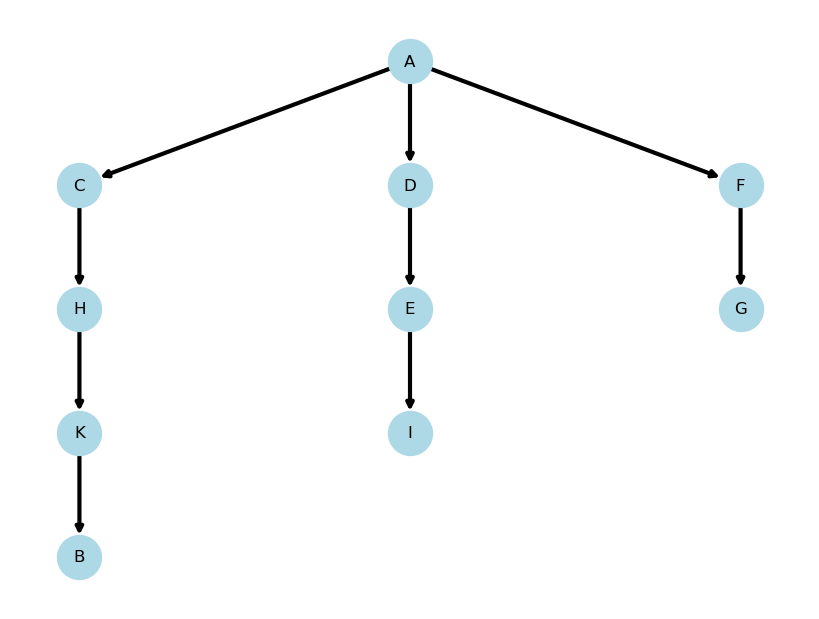

In [20]:
G = nx.DiGraph()
for u in ADJ:
    for v in sorted(ADJ[u]):
        G.add_edge(u,v)

plt.figure(figsize=(8, 6))

P = nx.dfs_tree(G, source='A')
pos = hierarchy_pos(P,'A')

nx.draw(P, pos, with_labels=True,node_size=1000, node_color="lightblue",width=3 )
plt.savefig("dfs.png")
plt.show()

# Kết thúc